In [2]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt

In [9]:
mech = "gri30.yaml"
gas = ct.Solution(mech)
Tu = 300 #K
Pu = ct.one_atm
gas.TP = Tu, Pu
phi = 0.7
fuel = 'CH4:1.0'
air = 'O2:1.0, N2:3.76'

# Set the composition
gas.set_equivalence_ratio(phi, fuel, air)
## Free flame with F=1
freeflame = ct.FreeFlame(gas,width=0.16)
freeflame.flame.set_stretched_thickened_flame(1.0,1.0,1.0) # Set Fsp, Fth and Fr =1
freeflame.flame.transport_model='simplified'
gas.set_lewis_number(1.8)
gas.set_prandtl_number(0.7)
freeflame.set_refine_criteria(ratio=3, slope=0.05, curve=0.1)
# stage one
freeflame.solve(loglevel=0, auto=False)

In [10]:
freeflame.flame.get_stretched_thickened_flame()

(1.0, 1.0, 1.0)

In [11]:
mech = "gri30.yaml"
gas = ct.Solution(mech)
Tu = 300 #K 
Pu = ct.one_atm
gas.TP = Tu, Pu
phi = 0.7
fuel = 'CH4:1.0'
air = 'O2:1.0, N2:3.76'

# Set the composition
gas.set_equivalence_ratio(phi, fuel, air)
## Free flame with F=1
freeflame2 = ct.FreeFlame(gas,width=0.16)
freeflame2.flame.set_stretched_thickened_flame(20.0,20.0,20.0) # Set Fsp, Fth and Fr =1
freeflame2.set_refine_criteria(ratio=3, slope=0.05, curve=0.1)
# stage one
freeflame2.solve(loglevel=0, auto=False)

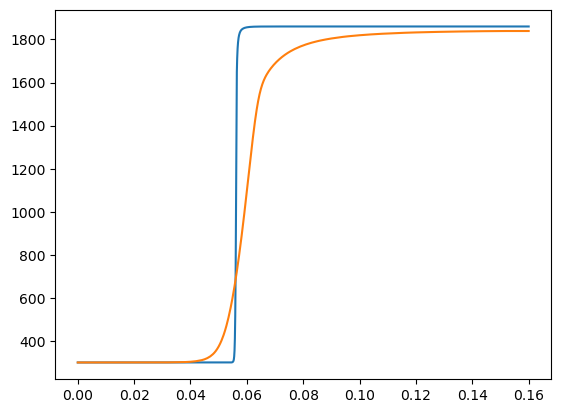

In [12]:
plt.plot(freeflame.grid,freeflame.T)
plt.plot(freeflame2.grid,freeflame2.T)

In [7]:
def thermal_flame_thickness(grid, T):
    """
    Compute thermal flame thickness using:
        δ_f = (T_max - T_min) / max(dT/dx)
    """
    dTdx = np.gradient(T, grid)
    Tmax = T.max()
    Tmin = T.min()
    return (Tmax - Tmin) / dTdx.max()


In [8]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import os
#os.chdir(os.path.dirname(os.path.abspath(__file__)))

p          =   101325   # pressure
tin        =   300.0    # unburned gas temperature
phi        =   0.8      # equivalence ratio


gas = ct.Solution('BFER_methane.yaml')

m = gas.n_species
x = np.zeros(m,'d')
fuel_species = 'CH4'
ifuel = gas.species_index(fuel_species)
io2 = gas.species_index('O2')

refine_grid = "disabled"
tol_ss    = [1.0e-5, 1.0e-8]        # [rtol atol] for steady-state problem
tol_ts    = [1.0e-5, 1.0e-8]        # [rtol atol] for time stepping
loglevel  = 1                       # amount of diagnostic output (0 to 5)

n_points = 5000
F = [1.0, 2.0, 5.0, 10.0, 15.0, 20.0]
temperature = []
position = []
df_list = []

for ind_thick, thick in enumerate(F):
    gas.set_equivalence_ratio(phi, 'CH4:1', 'O2:1.0, N2:3.76')
    gas.TP = tin, p
    initial_grid = np.linspace(0, 0.02, int(1000/thick))
    f = ct.FreeFlame(gas, grid=initial_grid)
    f.flame.transport_model='mixture'
    # This is where thickening is applied
    f.flame.set_stretched_thickened_flame(thick,thick,thick)


    f.energy_enabled = True
    f.flame.set_steady_tolerances(default=tol_ss)
    f.flame.set_transient_tolerances(default=tol_ts)
    f.inlet.X = gas.X
    f.inlet.T = tin
    #f.set_refine_criteria(ratio = 7.0, slope = 1, curve = 1)
    f.set_max_jac_age(50, 50)
    f.set_time_step(5.e-06, [10, 20, 80]) #s
    f.set_refine_criteria(ratio = 2.0, slope = 0.02, curve = 0.02, prune = 0.01)
    f.solve(loglevel, auto=True)

    temperature.append(f.T)
    position.append(f.flame.grid)
    df = thermal_flame_thickness(f.flame.grid, f.T)
    df_list.append(thermal_flame_thickness(f.flame.grid, f.T) * 1000)  # mm
    print("δ_f = ", df*1000, " mm")
    print("Flame speed:", f.velocity[0])

fig = plt.figure(figsize=(18,16))
a=fig.add_subplot(111)
for ind_thick, thick in enumerate(F):
    a.plot(position[ind_thick],temperature[ind_thick], label="F = "+str(thick))
plt.title(r'$T_{adiabatic}$ vs. Position', fontsize=25)
plt.xlabel(r'Position [m]', fontsize=20)
plt.ylabel("Adiabatic Flame Temperature [K]", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#a.xaxis.set_major_locator(MaxNLocator(10)) # this controls the number of tick marks on the axis
plt.legend(fontsize=15)

plt.show()

CanteraError: 
*******************************************************************************
CanteraError thrown by Factory::canonicalize:
No such type: 'mixture'
*******************************************************************************
